# Tufa Labs ARC3 submission

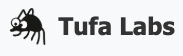

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
if TRUE_SUBMISSION:  # serving Qwen needs the eval GPU; the CPU-safe commit skips it
    for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
        print(f"taaf.kaggle: setup command: {command}", flush=True)
        subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
        env = _command_env()
        os.environ.update(env)
else:
    print("[duck] commit: skipping setup_commands (no GPU serve)", flush=True)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# duck-mem: memory + anti-waste patch stack (see harness_mem.py).
# Runs after the bundle loads and BEFORE bm.run() reads setup_commands.json,
# so P6 can edit the serving config in place. Fail-safe by construction.
# json/subprocess/Path are already bound in the notebook namespace by cell 8.
"""duck-mem: memory + anti-waste patch stack for the shipped duck-base v2 config.

Built for the 2026-08-11 00:01 UTC slot. Every patch is fail-safe: it verifies its
anchor before applying and degrades to a printed warning (never a crash) if the
bundled harness differs from the version this stack was written against. Nothing
here changes the model, sampling parameters, concurrency, per-game budget, the game
list, or the submission path. Behavioural deltas, in order:

  P1  token estimator len//4            (was (len+2)//3; measured 1.44x overcount)
  P2  middle-drop history trimmer       (was front-drop; keeps the KV prefix cache)
  P3  neutralize the "minimize actions" own-goal in GAME_OVERVIEW_ADDENDUM
  P4  repeated-no-effect batch guard    (faithful stock step_env copy + guard;
                                        NOTE: raw board_changed => inert on the
                                        18/25 HUD-ticker games; weak but safe)
  P5  analyzer yield 60 -> 90 s         GATED OFF (DUCK_MEM_P5=1 to arm): the
                                        sonpham tempo law (900s-yield cost 2.2x
                                        vs 60s act-look-act) argues against;
                                        unmeasured for us
  P6  adaptive memory expansion         GATED OFF (DUCK_MEM_P6=1 to arm): doubles
                                        per-request context on a 96GB GPU;
                                        contradicts the retune direction
                                        (65536->40960) and is unmeasured; edits
                                        the serve config — highest-risk item

Default stack (nothing armed) = P1-P4: a single coherent "anti-waste" theme.
Review 2026-08-10 (this repo): P3 as first written was a SILENT NO-OP —
tool_agent binds GAME_OVERVIEW_ADDENDUM by value at import time
(tool_agent.py:17-19) and reads the local name at :352, so patching the prompts
module alone changes nothing once tool_agent is imported (the hook cell runs
with `bm` already constructed). Fixed below by rebinding BOTH namespaces.

Reference: scratchpad/taaf_scored_ref/src (bundle snapshot aa69123, DIRTY).
"""
from __future__ import annotations

import json
import os
import subprocess
from pathlib import Path

ARM_MARKER = "[duck-mem]"

# P4 — only these display names are guard-worthy: same action, none of the
# board-changing machinery, most games expose them as the avatar directions.
_MEM_DIRECTIONS = frozenset({"UP", "DOWN", "LEFT", "RIGHT"})

_BUDGET_MAX_MODEL_LEN = 98304
_BUDGET_CONTEXT_WINDOW = 65536


# ---------------------------------------------------------------------------
# P1 — token estimator
# ---------------------------------------------------------------------------

def _estimate_tokens_impl(value) -> int:  # noqa: ANN001
    try:
        rendered = json.dumps(value, ensure_ascii=True, sort_keys=True, default=str)
    except TypeError:
        rendered = str(value)
    return max(1, (len(rendered) + 3) // 4)


def patch_token_estimator() -> bool:
    """((len+2)//3) -> ((len+3)//4). Errs high (~1.08x) so it cannot overrun the
    served window; recovers ~30% of the context we already pay for at zero prefill."""
    from inference.agent import tool_agent as ta

    if getattr(ta._estimate_tokens, "_mem", False):
        return True

    _estimate_tokens_impl._mem = True  # type: ignore[attr-defined]
    ta._estimate_tokens = _estimate_tokens_impl
    print(f"{ARM_MARKER} P1 estimator //4: OK", flush=True)
    return True


# ---------------------------------------------------------------------------
# P2 — middle-drop trimmer
# ---------------------------------------------------------------------------

def _drop_middle_history_block(self, history, *, preserve_recent):  # noqa: ANN001
    """Drop ONE full turn block from the middle of the history list, in place.

    Contract: same signature and True/False contract as the harness's
    `_drop_oldest_history_block`, but the head of history (system-adjacent turns)
    and the sacred tail (`preserve_recent` messages) survive, so the vLLM prefix
    cache is not invalidated on every trim."""
    removable = len(history) - preserve_recent
    if removable <= 0:
        return False
    if removable == 1:
        history.pop(0)
        return True
    sacred_from = len(history) - preserve_recent
    user_indexes = [
        i for i, m in enumerate(history)
        if str(m.get("role", "")).strip() == "user" and i < sacred_from
    ]
    if not user_indexes:
        history.pop(0)
        while history and history[0].get("role") == "tool" and len(history) > preserve_recent:
            history.pop(0)
        return True
    mid = len(history) // 2
    target = min(user_indexes, key=lambda i: abs(i - mid))
    block_end = target + 1
    while block_end < sacred_from and history[block_end].get("role") != "user":
        block_end += 1
    del history[target:block_end]
    return True


def patch_middle_drop() -> bool:
    """Replace front-drop eviction with middle-drop. Keeps the head of history
    (system prompt + earliest turns) intact so vLLM prefix caching survives trims
    (measured 49.3% hit rate, currently invalidated on every front trim), and the
    model keeps the early-findings context that front-drop destroys."""
    from inference.agent import tool_agent as ta

    cls = ta.ToolAgent
    if getattr(cls, "_mem_middle_drop", False):
        return True
    _drop_middle_history_block._mem = True  # type: ignore[attr-defined]
    cls._mem_middle_drop = True  # type: ignore[attr-defined]
    cls._drop_oldest_history_block = _drop_middle_history_block
    print(f"{ARM_MARKER} P2 middle-drop trimmer: OK", flush=True)
    return True


# ---------------------------------------------------------------------------
# P3 — prompt own-goal neutralization
# ---------------------------------------------------------------------------

_OLD_OPTIMIZE_LINE = "- Optimize for as few in-game actions as possible while still being reliable.\n"
_NEW_OPTIMIZE_LINE = (
    "- Completing levels is the goal; exploration that reveals mechanics is worth its actions.\n"
)


def patch_prompt_own_goal() -> bool:
    """The 'minimize actions' line is an own-goal: the completion-share cap binds
    long before efficiency (8/10 measured completed levels are cap-bound), and the
    instruction suppresses the exploration that unlocks depth.

    MUST rebind in BOTH namespaces: tool_agent imports GAME_OVERVIEW_ADDENDUM by
    value (`from inference.agent.prompts import GAME_OVERVIEW_ADDENDUM`,
    tool_agent.py:17-19) and _build_system_prompt reads the LOCAL binding
    (tool_agent.py:352). Patching prompts alone is a silent no-op."""
    from inference.agent import prompts
    from inference.agent import tool_agent as ta

    anchor = prompts.GAME_OVERVIEW_ADDENDUM
    if _OLD_OPTIMIZE_LINE not in anchor:
        print(f"{ARM_MARKER} P3 prompt anchor MISSING (already neutralized?)", flush=True)
        return False
    replacement = anchor.replace(_OLD_OPTIMIZE_LINE, _NEW_OPTIMIZE_LINE)
    assert replacement != anchor
    prompts.GAME_OVERVIEW_ADDENDUM = replacement
    ta.GAME_OVERVIEW_ADDENDUM = replacement
    if _OLD_OPTIMIZE_LINE in getattr(ta, "GAME_OVERVIEW_ADDENDUM", ""):
        print(f"{ARM_MARKER} P3 tool_agent rebind FAILED", flush=True)
        return False
    print(f"{ARM_MARKER} P3 prompt own-goal neutralized (both namespaces): OK", flush=True)
    return True


# ---------------------------------------------------------------------------
# P4 — repeated-no-effect batch guard (engine level)
# ---------------------------------------------------------------------------

# ---------------------------------------------------------------------------
# P4 — repeated-no-effect batch guard (engine level)
# ---------------------------------------------------------------------------

def _should_guard_no_effect(board_changed: bool, action_display, next_display) -> bool:  # noqa: ANN001
    """Guard rule: the executed action is a direction, it changed nothing on the
    visible board, and the batch's next action repeats the same direction."""
    if board_changed:
        return False
    if action_display not in _MEM_DIRECTIONS:
        return False
    return action_display == next_display


def patch_repeated_no_effect_guard() -> bool:
    """If a direction leaves the entire visible board unchanged, do not repeat that
    same direction inside the current batch. Return control for re-observation."""
    import inference.framework.solver as solver

    session = solver._HarnessGameSession
    if getattr(session, "_mem_no_effect_guard", False):
        return True
    current = getattr(session.step_env, "__name__", "") == "step_env"
    if not current:
        print(f"{ARM_MARKER} P4 guard SKIPPED: step_env already replaced", flush=True)
        return False

    def _step_env(self, arguments):  # noqa: ANN001, ANN202
        requested_actions, error = self._normalize_actions(arguments)
        if error is not None or requested_actions is None:
            return self._error_payload(error or "Could not parse action request.")
        if self.should_stop() or solver._is_engine_game_over(self.game):
            return self._terminal_payload(requested_actions)

        executed_payloads = []
        total_reward = 0.0
        stop_reason = None
        stop_detail = None
        batch_size = len(requested_actions)
        requested_displays = [
            solver._format_action_display(action.id.name, dict(action.data))
            for action in requested_actions
        ]

        for batch_index, action in enumerate(requested_actions, start=1):
            if self.should_stop():
                stop_reason = "stopped"
                break
            if action.id.value not in self.game.current_state.available_actions:
                message = (
                    f"{solver._format_action_display(action.id.name, dict(action.data))} "
                    "is not valid right now."
                )
                if executed_payloads:
                    stop_reason = "invalid_action"
                    break
                return self._error_payload(message)

            try:
                payload = self._execute_action(
                    action,
                    batch_index=batch_index,
                    batch_size=batch_size,
                    flush_viewer_payload=False,
                )
            except Exception as exc:  # noqa: BLE001
                if executed_payloads:
                    stop_reason = "action_error"
                    break
                return self._error_payload(f"{type(exc).__name__}: {exc}")
            executed_payloads.append(payload)
            total_reward += float(payload.get("reward", 0.0) or 0.0)

            if payload.get("run_complete"):
                stop_reason = "run_complete"
                break
            if payload.get("game_over"):
                stop_reason = "game_over"
                break
            if payload.get("level_completed"):
                stop_reason = "level_completed"
                break

            action_display = requested_displays[batch_index - 1]
            next_display = requested_displays[batch_index] if batch_index < batch_size else None
            if _should_guard_no_effect(payload.get("board_changed"), action_display, next_display):
                stop_reason = "repeated_no_effect"
                stop_detail = (
                    f"Stopped before repeating {action_display}: the previous identical "
                    "direction left the visible board unchanged. Re-observe before retrying."
                )
                break

        if not executed_payloads:
            return self._error_payload("No action was executed.")

        final_payload = dict(executed_payloads[-1])
        final_payload["reward"] = total_reward
        final_payload["last_reward"] = executed_payloads[-1].get("reward", 0.0)
        final_payload["batched"] = batch_size > 1
        final_payload["requested_count"] = batch_size
        final_payload["executed_count"] = len(executed_payloads)
        final_payload["requested_actions"] = requested_displays
        final_payload["executed_actions"] = [
            str(item.get("action_display") or item.get("action_name") or "")
            for item in executed_payloads
        ]
        final_payload["board_changed"] = any(
            bool(item.get("board_changed")) for item in executed_payloads
        )
        final_payload["stopped_early"] = len(executed_payloads) < batch_size
        if stop_reason is not None:
            final_payload["stop_reason"] = stop_reason
        if stop_detail is not None:
            final_payload["stop_detail"] = stop_detail
        self.write_viewer_payload()
        return final_payload

    _step_env._mem = True  # type: ignore[attr-defined]
    session._mem_no_effect_guard = True  # type: ignore[attr-defined]
    session.step_env = _step_env
    print(f"{ARM_MARKER} P4 repeated-no-effect guard: OK", flush=True)
    return True


# ---------------------------------------------------------------------------
# P5 — analyzer yield
# ---------------------------------------------------------------------------

def patch_yield_seconds(seconds: float = 90.0) -> bool:
    from inference.agent import tool_agent as ta

    old = ta._LOCAL_ANALYZER_YIELD_SECONDS
    ta._LOCAL_ANALYZER_YIELD_SECONDS = float(seconds)
    os.environ["LOCAL_ANALYZER_YIELD_SECONDS"] = str(seconds)
    print(f"{ARM_MARKER} P5 yield {old!r} -> {seconds}: OK", flush=True)
    return True


# ---------------------------------------------------------------------------
# P6 — adaptive memory expansion (the 96 GB finding)
# ---------------------------------------------------------------------------

def _detected_vram_mb() -> int:
    try:
        out = subprocess.run(
            ["nvidia-smi", "--query-gpu=memory.total", "--format=csv,noheader,nounits"],
            capture_output=True, text=True, timeout=15, check=False,
        )
        first = out.stdout.strip().splitlines()[0] if out.stdout.strip() else ""
        return int(first)
    except Exception:  # noqa: BLE001
        return 0


def patch_adaptive_memory(bundle_dir) -> bool:  # noqa: ANN001
    """Setup commands run AFTER this hook (bm.run reads setup_commands.json at run
    time), so edit the file in place. Only expands when the eval GPU has the VRAM:
    RTX Pro 6000 (Blackwell) = 96 GB runs max-model-len 98304 + window 65536;
    a smaller machine keeps the shipped 65536/32768 (identical bytes behaviour)."""
    setup_path = Path(bundle_dir) / "setup_commands.json"
    if not setup_path.exists():
        print(f"{ARM_MARKER} P6 setup_commands.json NOT FOUND — skipped", flush=True)
        return False
    commands = json.loads(setup_path.read_text())
    vram_mb = _detected_vram_mb()
    changed = False
    if vram_mb >= 80000 and isinstance(commands, list) and commands:
        edition = commands[0]
        for old, new in (
            ("VLLM_MAX_MODEL_LEN = 65536", f"VLLM_MAX_MODEL_LEN = {_BUDGET_MAX_MODEL_LEN}"),
            ("ANALYZER_CONTEXT_WINDOW = 32768", f"ANALYZER_CONTEXT_WINDOW = {_BUDGET_CONTEXT_WINDOW}"),
        ):
            if old in edition and new not in edition:
                edition = edition.replace(old, new)
                changed = True
        commands[0] = edition
        if changed:
            setup_path.write_text(json.dumps(commands))
            print(
                f"{ARM_MARKER} P6 memory expansion VRAM={vram_mb}MB: "
                f"max-model-len {_BUDGET_MAX_MODEL_LEN} + window {_BUDGET_CONTEXT_WINDOW}: OK",
                flush=True,
            )
        else:
            print(f"{ARM_MARKER} P6 memory expansion: anchors missing, no change", flush=True)
    elif vram_mb < 80000:
        print(f"{ARM_MARKER} P6 memory expansion SKIPPED (VRAM={vram_mb}MB < 80000)", flush=True)
    return True


# ---------------------------------------------------------------------------
# driver
# ---------------------------------------------------------------------------

def apply_all(bundle_dir) -> None:  # noqa: ANN001
    print(f"{ARM_MARKER} applying patch stack", flush=True)
    ok = [
        patch_token_estimator(),
        patch_middle_drop(),
        patch_prompt_own_goal(),
        patch_repeated_no_effect_guard(),
    ]
    armed = len(ok)
    # P5/P6 are gated OFF by default: no supporting measurement, and held
    # counter-evidence (tempo law; retune direction). See module docstring.
    if os.environ.get("DUCK_MEM_P5", "0") == "1":
        ok.append(patch_yield_seconds(90.0))
        armed += 1
    else:
        print(f"{ARM_MARKER} P5 yield: GATED OFF", flush=True)
    if os.environ.get("DUCK_MEM_P6", "0") == "1":
        ok.append(patch_adaptive_memory(bundle_dir))
        armed += 1
    else:
        print(f"{ARM_MARKER} P6 memory expansion: GATED OFF", flush=True)
    print(f"{ARM_MARKER} patch stack applied: {sum(1 for v in ok if v)}/{armed}", flush=True)

apply_all(BUNDLE_DIR)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    if TRUE_SUBMISSION:
        await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    else:
        import pandas as pd
        pd.DataFrame([["1_0", "1", True, 1]],
                     columns=["row_id", "game_id", "end_of_game", "score"]
                     ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
        print("[duck] commit: CPU-safe landing; scored rerun runs the plain duck", flush=True)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")